In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import math

In [3]:
df=pd.read_csv("spambase_csv.csv")
df.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [4]:
X=df.drop('class',axis=1)
y=df['class']
print("Missing values:", X.isnull().sum().sum())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print(X_scaled.describe())

Missing values: 0
       word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
count    4.601000e+03       4.601000e+03   4.601000e+03   4601.000000   
mean     1.853187e-17       2.779780e-17   2.470916e-17      0.000000   
std      1.000109e+00       1.000109e+00   1.000109e+00      1.000109   
min     -3.424337e-01      -1.650719e-01  -5.567606e-01     -0.046900   
25%     -3.424337e-01      -1.650719e-01  -5.567606e-01     -0.046900   
50%     -3.424337e-01      -1.650719e-01  -5.567606e-01     -0.046900   
75%     -3.424337e-01      -1.650719e-01   2.764271e-01     -0.046900   
max      1.452700e+01       1.090096e+01   9.560519e+00     30.641278   

       word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
count   4.601000e+03    4.601000e+03      4.601000e+03         4601.000000   
mean    4.941832e-17    3.706374e-17     -2.470916e-17            0.000000   
std     1.000109e+00    1.000109e+00      1.000109e+00            1.000109   
min    -4.64

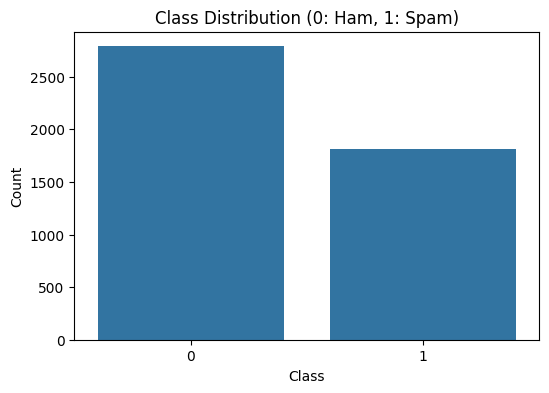

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title('Class Distribution (0: Ham, 1: Spam)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

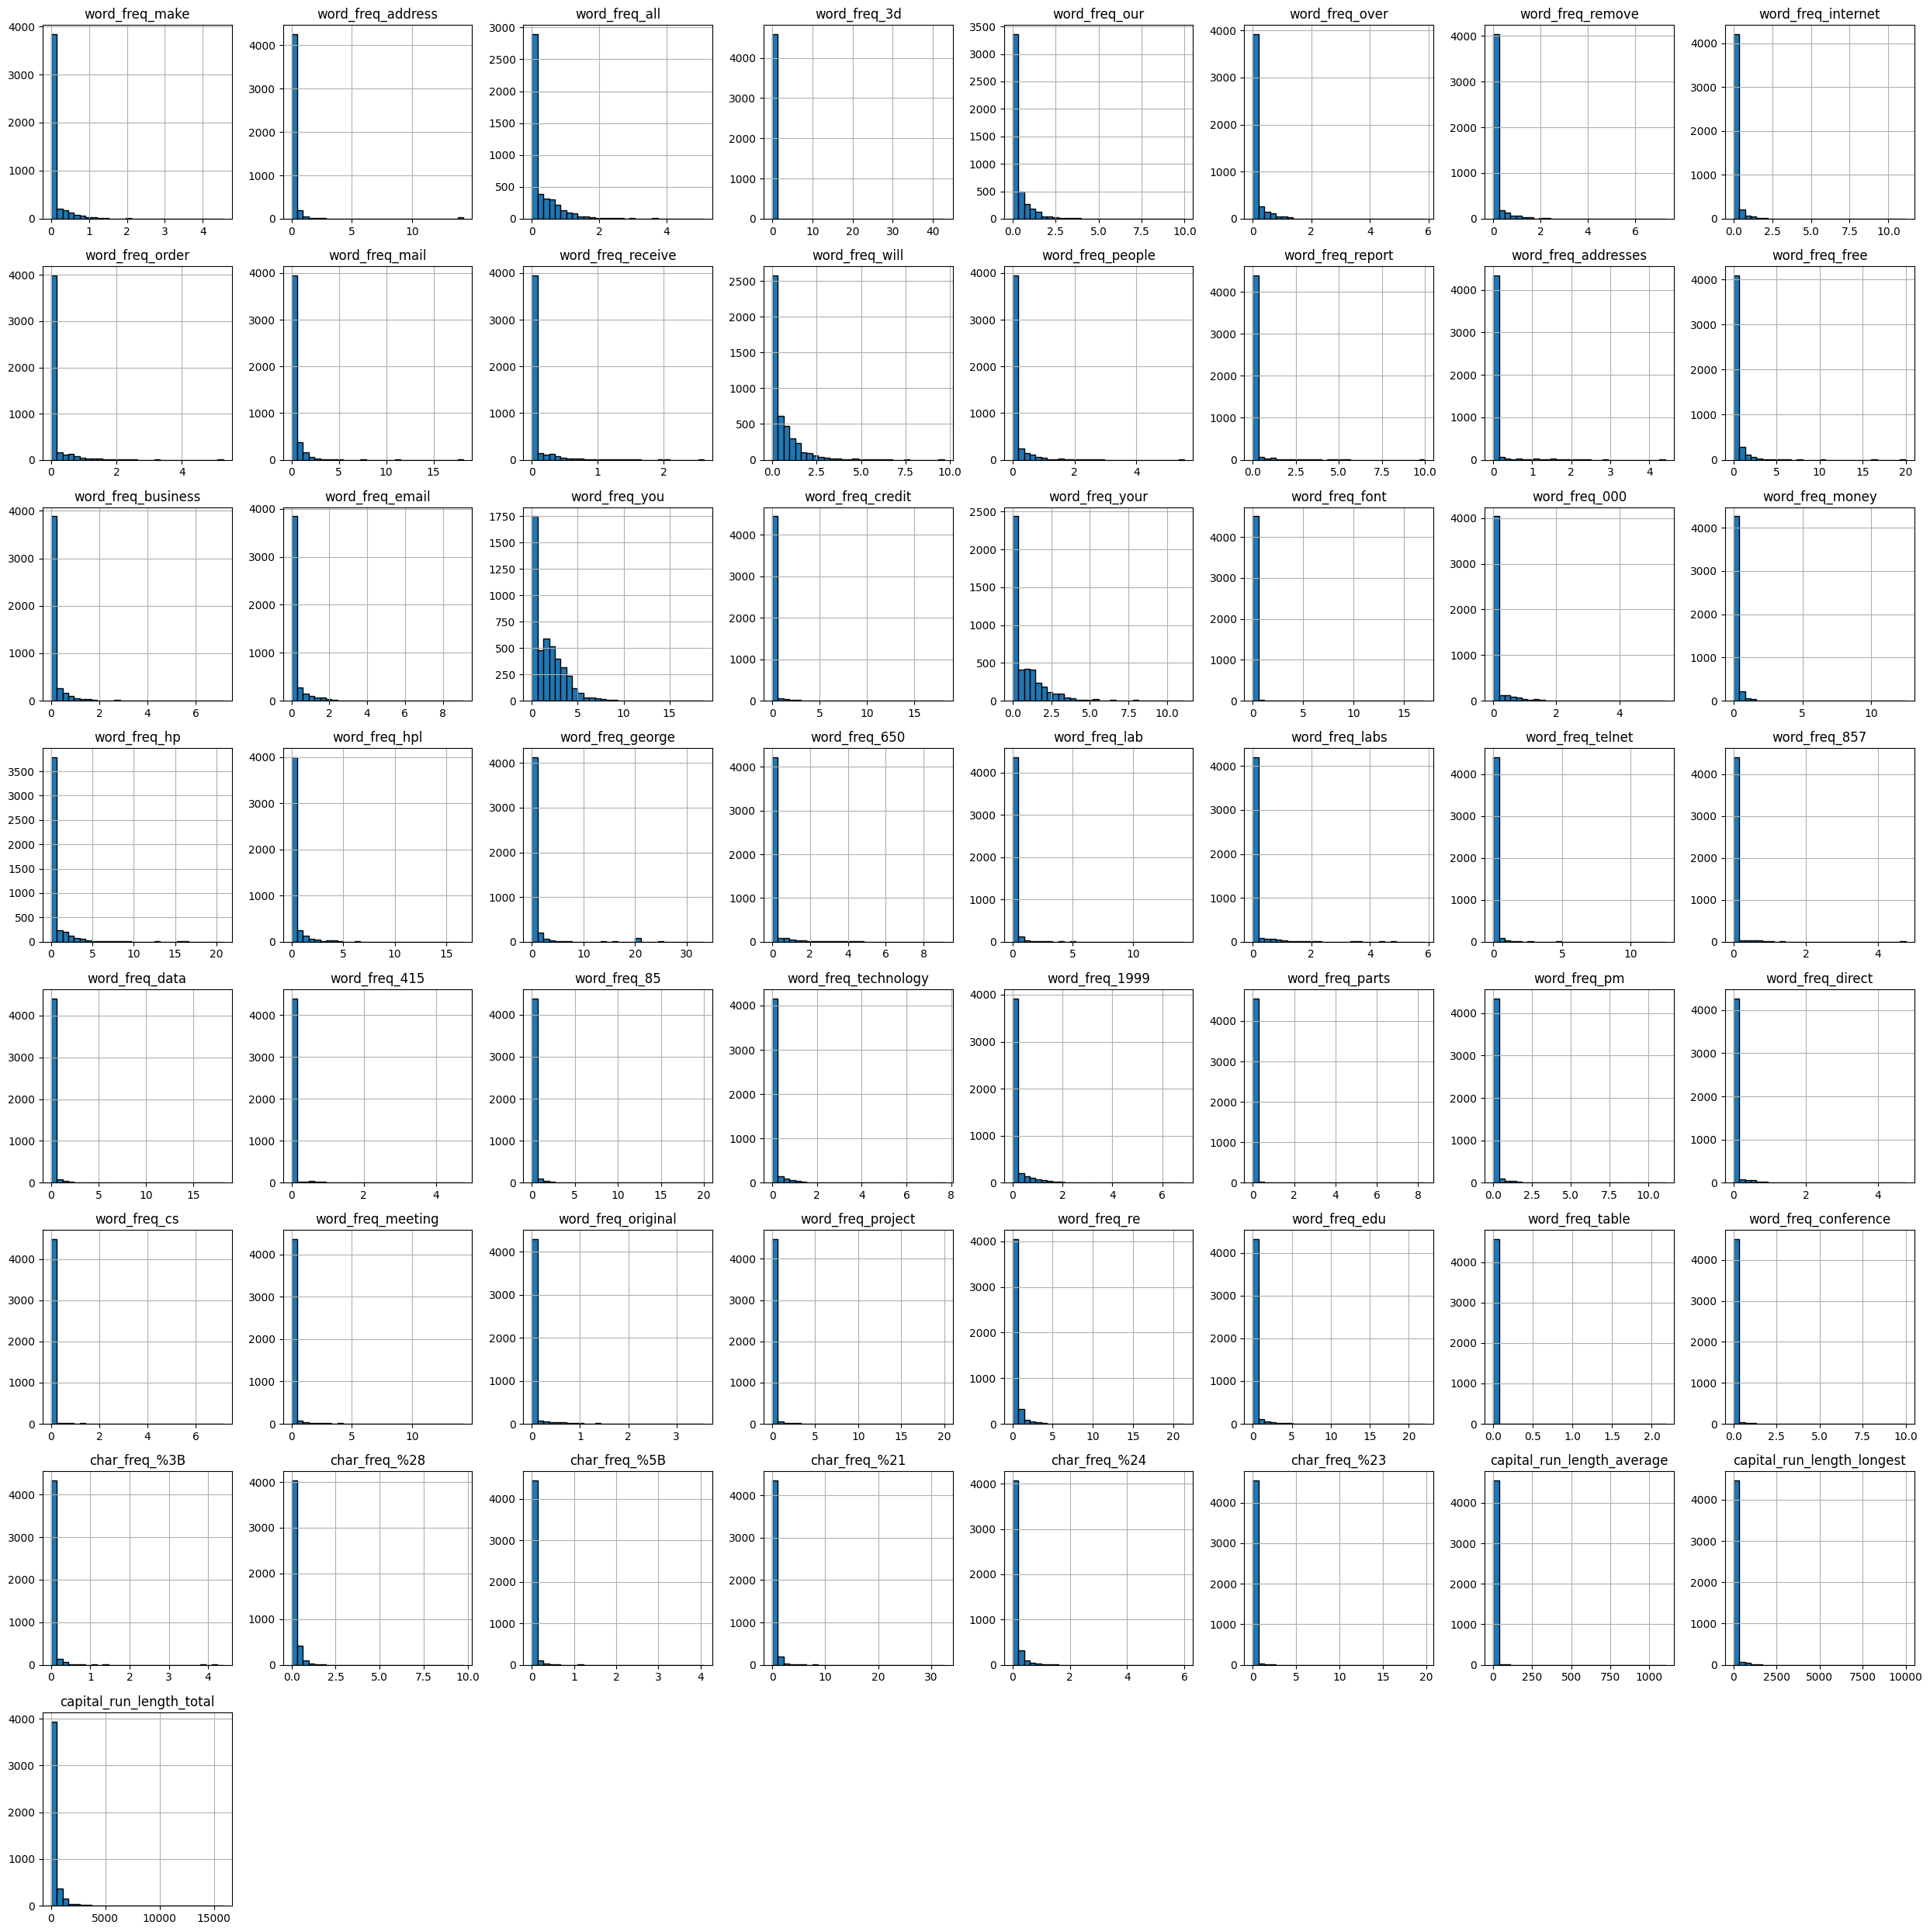

In [6]:
X.hist(
    bins=30,
    figsize=(25, 25),
    layout=(8, 8),   # adjust if needed
    edgecolor='black'
)

plt.tight_layout()
plt.show()

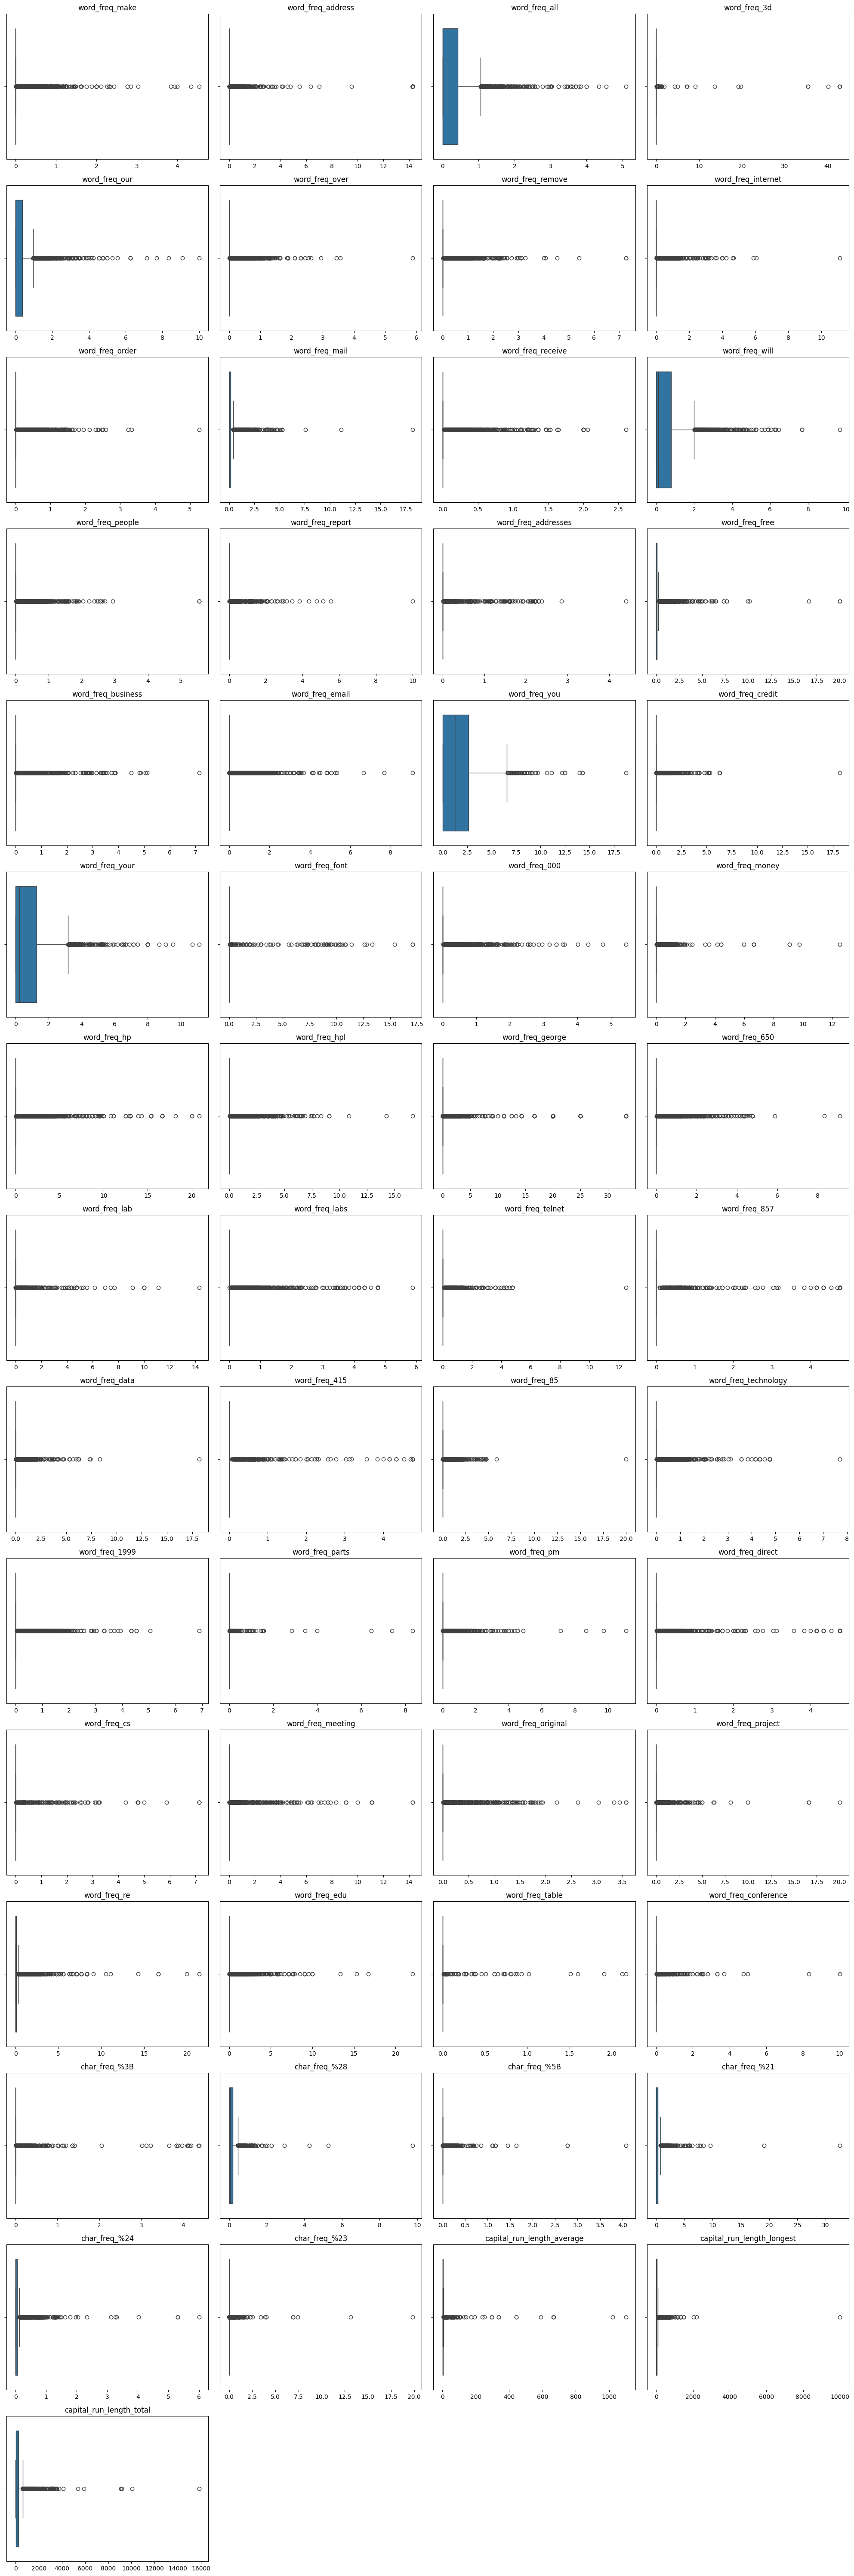

In [10]:
numerical_cols = X.columns

# Decide number of columns per row
n_cols = 4
n_rows = math.ceil(len(numerical_cols) / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

# Plot each boxplot separately
for i, col in enumerate(numerical_cols):
    sns.boxplot(x=X[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')

# Remove empty plots if any
for i in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


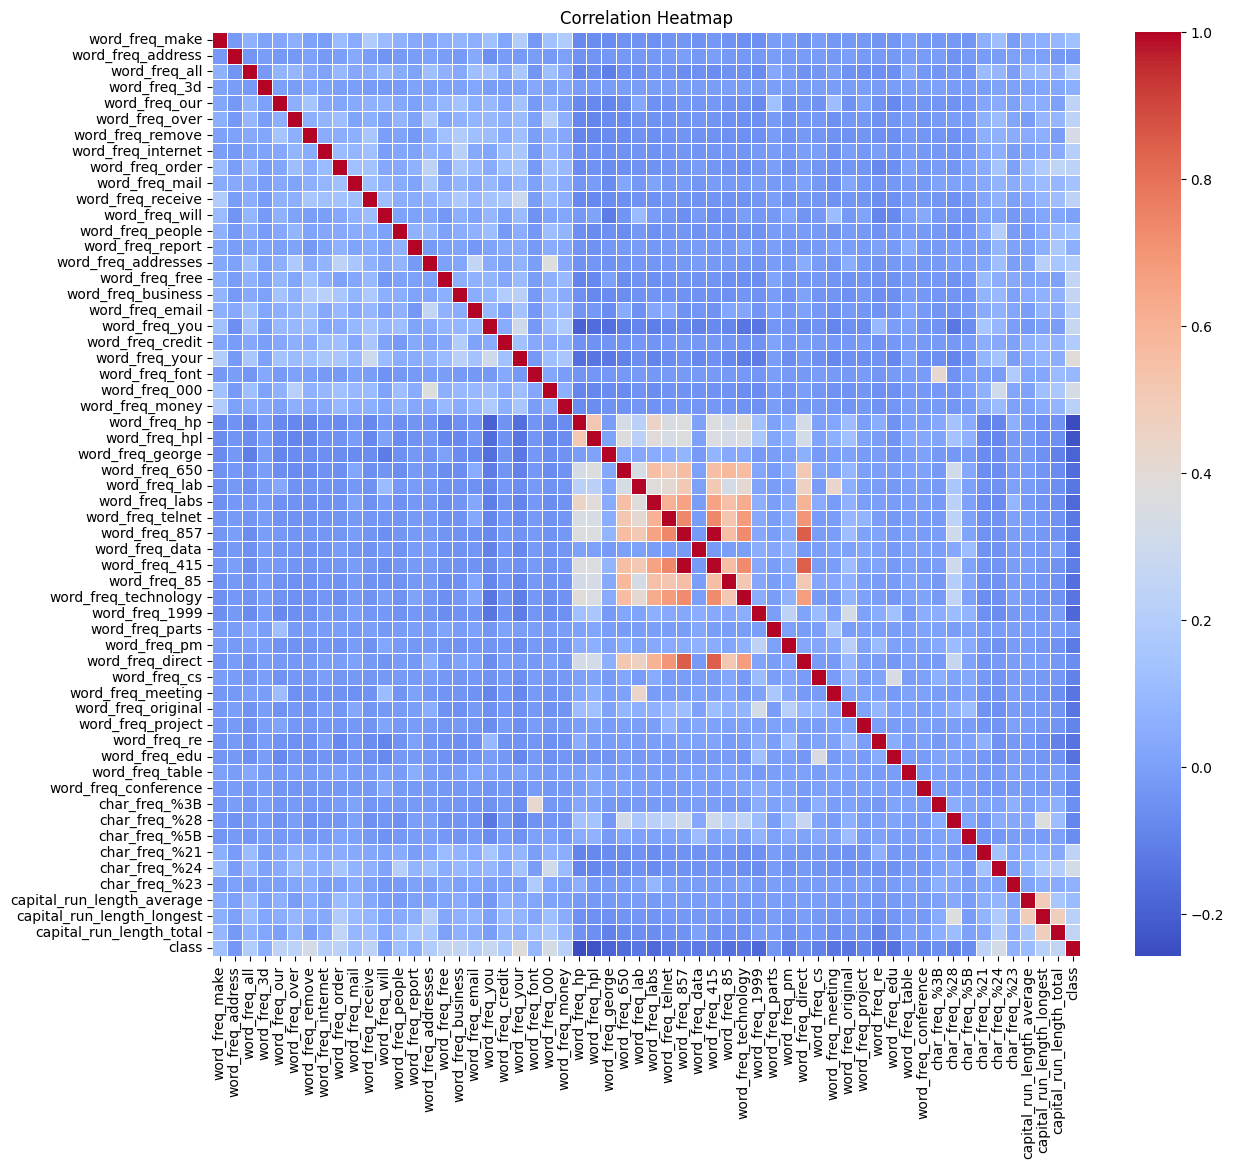

In [9]:
corr_matrix = df.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [11]:
# 4) Split the dataset into training and testing sets.

import pandas as pd
from sklearn.model_selection import train_test_split

# Load
df = pd.read_csv("spambase_csv.csv")

# Split features/target
X = df.drop("class", axis=1)
y = df["class"]

# Stratified split to preserve spam/non-spam ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape, y_train.mean(), y_test.mean()


((3680, 57),
 (921, 57),
 np.float64(0.39402173913043476),
 np.float64(0.3941368078175896))

In [14]:
# 5) Train baseline Logistic Regression.
lr_start = time.time()
lr_base = LogisticRegression(max_iter=5000)
lr_base.fit(X_train, y_train)
lr_end = time.time()
lr_preds = lr_base.predict(X_test)

print(f"Baseline LR Training Time: {lr_end - lr_start:.4f} s")
print("Baseline LR Metrics:")
print(classification_report(y_test, lr_preds))


Baseline LR Training Time: 1.0831 s
Baseline LR Metrics:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       558
           1       0.92      0.90      0.91       363

    accuracy                           0.93       921
   macro avg       0.93      0.92      0.92       921
weighted avg       0.93      0.93      0.93       921



In [15]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1', 'l2']
}

grid_lr = GridSearchCV(LogisticRegression(max_iter=5000), param_grid_lr, cv=5, n_jobs=-1, scoring='accuracy')
grid_lr.fit(X_train, y_train)

print("Best LR Parameters:", grid_lr.best_params_)
print("Best LR Cross-Validation Accuracy:", grid_lr.best_score_)

Best LR Parameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best LR Cross-Validation Accuracy: 0.9269021739130434


C:\Users\mahad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\mahad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [16]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
results_svm = []

for k in kernels:
    svc_temp = SVC(kernel=k, max_iter=5000)
    start_t = time.time()
    svc_temp.fit(X_train, y_train)
    end_t = time.time()

    preds = svc_temp.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    results_svm.append({
        'Kernel': k,
        'Accuracy': acc,
        'F1 Score': f1,
        'Training Time (s)': end_t - start_t
    })

svm_df = pd.DataFrame(results_svm)
print(svm_df)
     

C:\Users\mahad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
C:\Users\mahad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    Kernel  Accuracy  F1 Score  Training Time (s)
0   linear  0.714441  0.504708           0.152087
1     poly  0.646037  0.197044           0.424794
2      rbf  0.705755  0.555008           0.476933
3  sigmoid  0.606949  0.495822           0.275589


In [17]:
param_grid_svm = [

    {'kernel': ['linear'], 'C': [0.1, 1, 10, 100]},


    {'kernel': ['rbf', 'sigmoid'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']},


    {'kernel': ['poly'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto'], 'degree': [2, 3, 4]}
]


grid_svm = GridSearchCV(SVC(max_iter=5000), param_grid_svm, cv=3, n_jobs=-1, scoring='accuracy')
grid_svm.fit(X_train, y_train)

print("Best SVM Parameters:", grid_svm.best_params_)
print("Best SVM Cross-Validation Accuracy:", grid_svm.best_score_)


Best SVM Parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Best SVM Cross-Validation Accuracy: 0.8366817301313167


C:\Users\mahad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [18]:
results = pd.DataFrame(grid_svm.cv_results_)
results = results.sort_values(by='mean_test_score', ascending=False)
print(results[['param_kernel', 'param_C', 'mean_test_score', 'std_test_score']].head(10))


   param_kernel  param_C  mean_test_score  std_test_score
14          rbf     10.0         0.836682        0.009751
18          rbf    100.0         0.832606        0.007422
10          rbf      1.0         0.819290        0.008653
16          rbf    100.0         0.811688        0.012280
12          rbf     10.0         0.734240        0.006866
0        linear      0.1         0.711171        0.076815
8           rbf      1.0         0.708969        0.004694
2        linear     10.0         0.686681        0.027333
4           rbf      0.1         0.686143        0.005800
26         poly      1.0         0.680166        0.014282


In [22]:

best_lr = grid_lr.best_estimator_
best_svm = grid_svm.best_estimator_

def evaluate_model_full(model, X_train, y_train, X_test, y_test, name):

    start_train = time.time()
    model.fit(X_train, y_train)
    end_train = time.time()
    train_time = end_train - start_train


    start_infer = time.time()
    preds = model.predict(X_test)
    end_infer = time.time()
    infer_time = end_infer - start_infer

    print(f"--- {name} Performance ---")
    print(f"Training Time: {train_time:.4f} s")
    print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")
    print(f"Precision: {precision_score(y_test, preds):.4f}")
    print(f"Recall: {recall_score(y_test, preds):.4f}")
    print(f"F1 Score: {f1_score(y_test, preds):.4f}")
    print("-" * 30)
evaluate_model_full(best_lr, X_train, y_train, X_test, y_test, "Logistic Regression (Best)")
evaluate_model_full(best_svm, X_train, y_train, X_test, y_test, "SVM (Best)")
     

C:\Users\mahad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\mahad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


--- Logistic Regression (Best) Performance ---
Training Time: 0.0160 s
Accuracy: 0.9283
Precision: 0.9207
Recall: 0.8953
F1 Score: 0.9078
------------------------------


C:\Users\mahad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


--- SVM (Best) Performance ---
Training Time: 0.5246 s
Accuracy: 0.8436
Precision: 0.7717
Recall: 0.8567
F1 Score: 0.8120
------------------------------


In [24]:
from sklearn.model_selection import cross_val_score

print("Running Cross-Validation... (this may take a moment)")

cv_lr_scores = cross_val_score(best_lr, X_scaled, y, cv=5)
cv_svm_scores = cross_val_score(best_svm, X_scaled, y, cv=5)

cv_table = pd.DataFrame({
    'Fold': ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5'],
    'Logistic Regression': cv_lr_scores,
    'SVM': cv_svm_scores
})

average_row = {
    'Fold': 'Average',
    'Logistic Regression': cv_lr_scores.mean(),
    'SVM': cv_svm_scores.mean()
}

cv_table = pd.concat([cv_table, pd.DataFrame([average_row])], ignore_index=True)

print("\n--- K-Fold Cross-Validation Results (K=5) ---")
print(cv_table)   # ← replaced to_markdown() with normal print


Running Cross-Validation... (this may take a moment)


C:\Users\mahad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\mahad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\mahad\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty=


--- K-Fold Cross-Validation Results (K=5) ---
      Fold  Logistic Regression       SVM
0   Fold 1             0.917481  0.935939
1   Fold 2             0.928261  0.927174
2   Fold 3             0.931522  0.944565
3   Fold 4             0.942391  0.938043
4   Fold 5             0.827174  0.852174
5  Average             0.909366  0.919579
